In [1]:
import torch
from torch import nn
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
import numpy as np
import my_bar
import importlib
importlib.reload(my_bar)

<module 'my_bar' from '/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/code/my_bar.py'>

In [2]:
ours = True

In [3]:
if ours:
    x_numpy, y_numpy = my_bar.load_experimental_data()
else:
    x_numpy, y_numpy = my_bar.load_sciro_data()

x_numpy shape: (1138, 10)
y_numpy shape: (1138, 2)


In [4]:
x_normalized, x_means, x_stds = my_bar.normalize(x_numpy)
y_normalized, y_means, y_stds = my_bar.normalize(y_numpy)

x_denormalized = my_bar.denormalize(x_normalized, x_means, x_stds)
y_denormalized = my_bar.denormalize(y_normalized, y_means, y_stds)

In [5]:
if True:
    x_numpy = x_normalized
    y_numpy = y_normalized

In [6]:
x_train, y_train, x_val, y_val, x_test, y_test = my_bar.train_validation_test(x_numpy, y_numpy)

In [7]:
num_samples = x_numpy.shape[0]
num_input_dims = x_numpy.shape[1]
num_output_dims = y_numpy.shape[1]
sequence_length = 10

x_train_chunked, y_train_chunked = my_bar.chunk_sequence(x_train, y_train, sequence_length)
x_val_chunked, y_val_chunked = my_bar.chunk_sequence(x_val, y_val, sequence_length)
x_test_chunked, y_test_chunked = my_bar.chunk_sequence(x_test, y_test, sequence_length)

# Outputs
print(f"x_train_chunked shape: {x_train_chunked.shape}")  # Expected: (num_samples - sequence_length + 1, sequence_length, num_input_dims)
print(f"y_train_chunked shape: {y_train_chunked.shape}")  # Expected: (num_samples - sequence_length + 1, num_output_dims)

x_train_chunked shape: (787, 10, 10)
y_train_chunked shape: (787, 2)


In [8]:
train_loader = my_bar.prepare_dataloader(x_train_chunked, y_train_chunked, 16, True)
val_loader = my_bar.prepare_dataloader(x_val_chunked, y_val_chunked, 16, False)
test_loader = my_bar.prepare_dataloader(x_test_chunked, y_test_chunked, 16, False)

In [9]:
for batch in train_loader:
    x_batch, y_batch = batch
    print(x_batch.shape)
    print(y_batch.shape)
    break

torch.Size([16, 10, 10])
torch.Size([16, 2])


In [10]:
class TransformerRegressor(pl.LightningModule):
    def __init__(self, input_dim, output_dim, seq_len, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()

        # Positional Encoding
        self.positional_encoding = nn.Parameter(torch.zeros(1, seq_len, d_model))

        # Input Projection
        self.input_projection = nn.Linear(input_dim, d_model)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            activation="relu",
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Output Projection
        self.output_projection = nn.Linear(d_model, output_dim)

        # Learning Rate
        self.lr = lr

    def forward(self, x):
        # x: (batch_size, seq_len, input_dim)
        batch_size, seq_len, _ = x.size()

        # Add positional encoding
        x = self.input_projection(x) + self.positional_encoding[:, :seq_len, :]
        x = self.transformer_encoder(x)  # (batch_size, seq_len, d_model)

        # Pooling: Take the mean across the sequence dimension
        x = x.mean(dim=1)  # (batch_size, d_model)

        # Output projection
        return self.output_projection(x)  # (batch_size, output_dim)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = nn.MSELoss()(y_pred, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = nn.MSELoss()(y_pred, y)
        self.log("val_loss", loss)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = nn.MSELoss()(y_pred, y)
        self.log("test_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [11]:
# Instantiate the model
model = TransformerRegressor(
    input_dim=num_input_dims,
    output_dim=num_output_dims,
    seq_len=sequence_length,
)

# Define the trainer
trainer = pl.Trainer(max_epochs=20)

# Train the model
trainer.fit(model, train_loader, val_loader)

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                | Type               | Params | Mode 
-------------------------------------------------------------------
0 | input_projection    | Linear             | 704    | train
1 | transformer_encoder | TransformerEncoder | 66.9 K | train
2 | output_projection   | Linear             | 130    | train
  | other params        | n/a                | 640    | n/a  
-------------------------------------------------------------------
68.4 K    Trainable params
0         Non-trainable p

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


y_pred shape: torch.Size([162, 2])
y_test shape: torch.Size([162, 2])
Mean Squared Error (PyTorch): 9e+02
Mean Squared Error (PyTorch): 9.4012e+02


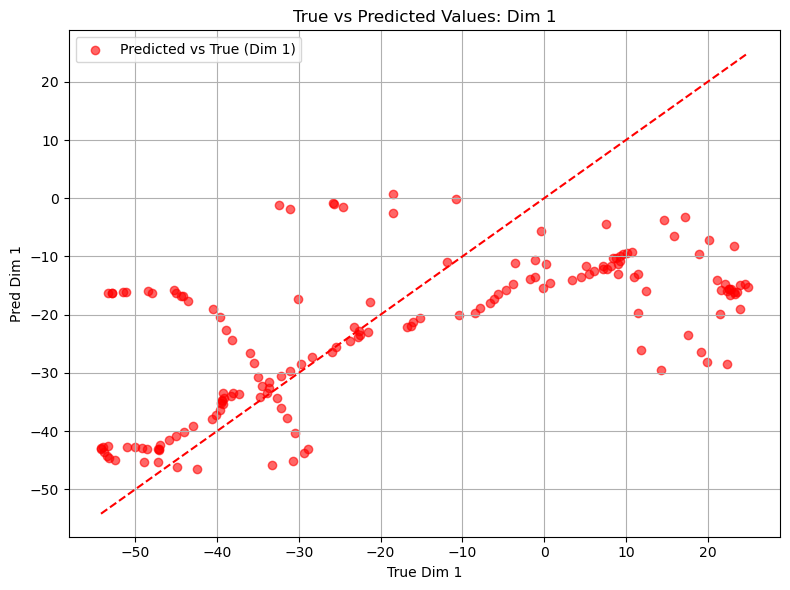

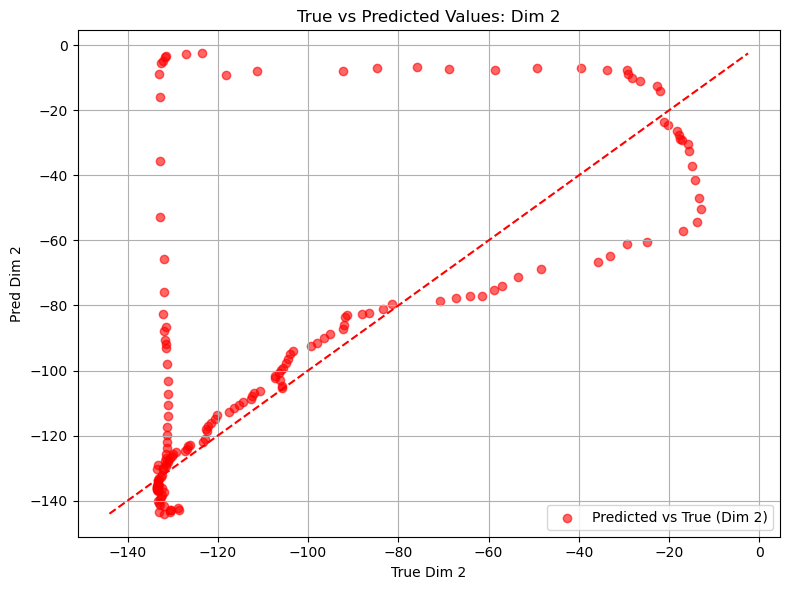

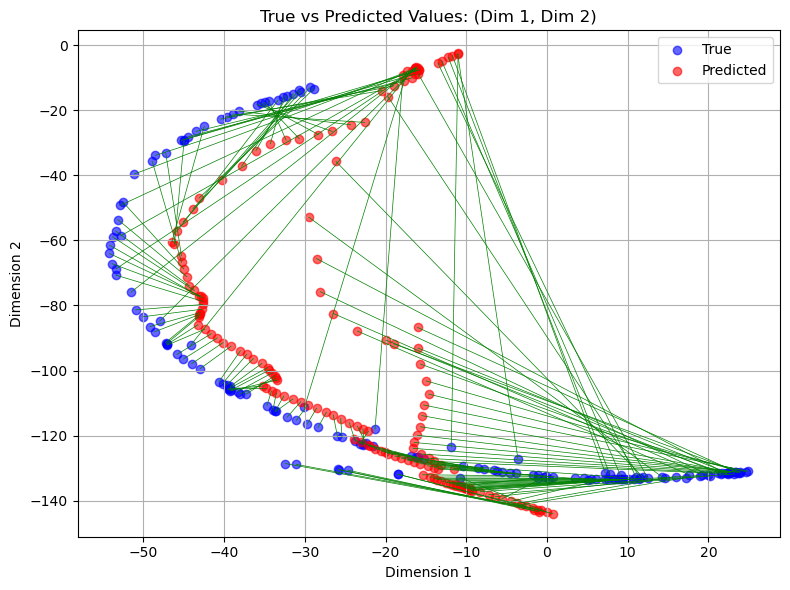

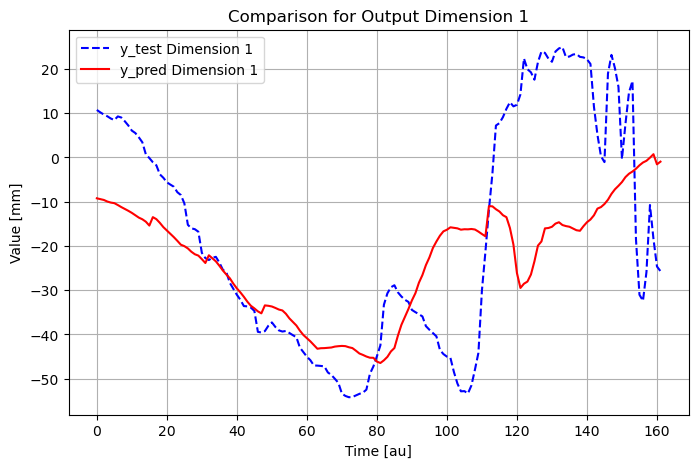

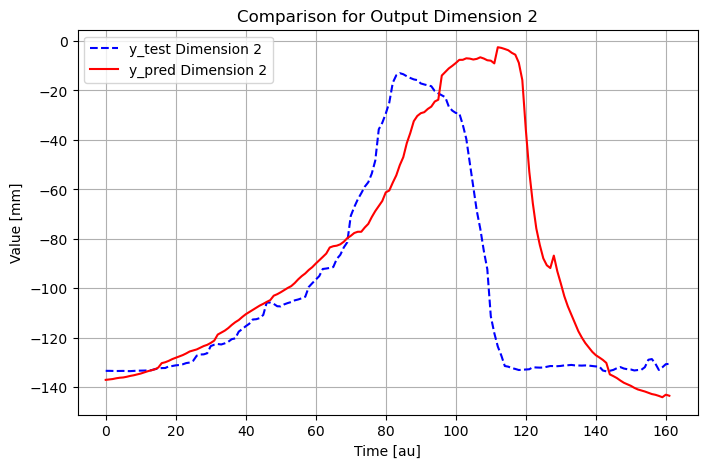

In [12]:
y_test, y_pred = my_bar.test_model(model, test_loader)
y_test_denormalised = my_bar.denormalize(y_test, y_means, y_stds)
y_pred_denormalised = my_bar.denormalize(y_pred, y_means, y_stds)
my_bar.print_mse(y_test_denormalised, y_pred_denormalised)
my_bar.plot_data(y_test_denormalised, y_pred_denormalised)